In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_ROOT = '/home/alexanderb/Zhang_lab/MML_model/data'

In [ ]:
DATA_ROOT = '/home/alexanderb/LEMBAS-RNN-benchmark'

### Recreate same data preprocessing as when creating model so can evaluate fairly

#load datasets
print('Loading Datasets')
#Load network
net = pd.read_csv(f"{DATA_ROOT}/Full data files/network(full).tsv", sep='\t')
print('Loaded Network')
#Load target gene expressions
gene_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/Geneexpression (full).tsv"), sep='\t', header=0)

Loading Datasets
Loaded Network


KeyboardInterrupt: 

In [9]:
logTPM_res = pd.read_csv(f'/home/alexanderb/Zhang_lab/MML_model/data/MSE_results_logTPM.csv', index_col = 0)
TPM_res = pd.read_csv(f'{DATA_ROOT}/MSE_results_TPM.csv', index_col = 0)

In [10]:
pd.melt(logTPM_res)

,variable,value
0,train_score,0.282701
1,train_score,0.007965
2,train_score,0.010157
3,train_score,0.022937
4,train_score,0.018540
...,...,...
32195,test_score,0.027930
32196,test_score,0.040121
32197,test_score,0.021523
32198,test_score,0.009393


In [11]:
log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

<Axes: xlabel='variable', ylabel='value'>

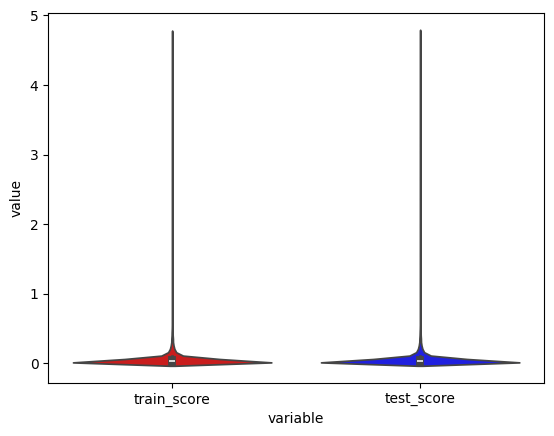

In [12]:
sns.violinplot(data = log_to_plot, x = 'variable', y="value", hue = 'variable', palette=['#e60000', '#0000ff'])

/tmp/ipykernel_1946274/3249008475.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


Text(0.5, 0.98, 'Per Gene MSE distribution (TPM)')

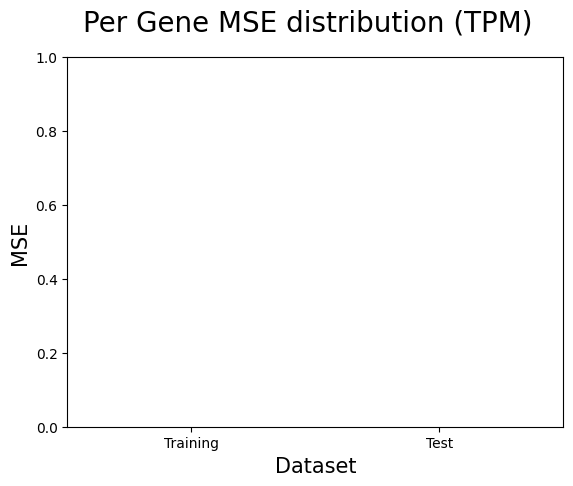

In [13]:
#create function make train test MSE violin plot

def loss_violin_plot(df, palette, title):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)

fig, ax = plt.subplots()
ax = sns.violinplot(data = TPM_to_plot, x = 'variable', y="value", hue = 'variable', palette=['#e60000', '#0000ff'])
ax.set_ylabel('MSE', fontsize = 15)
ax.set_xlabel('Dataset', fontsize = 15)
fig.canvas.draw()
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[0], labels[1] = ['Training', 'Test']
ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
fig.suptitle('Per Gene MSE distribution (TPM)', fontsize = 20)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_90313/3249008475.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


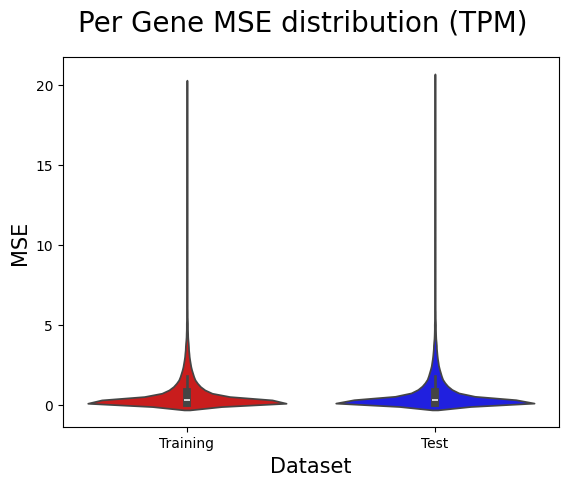

In [62]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)')

/tmp/ipykernel_1946274/3249008475.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


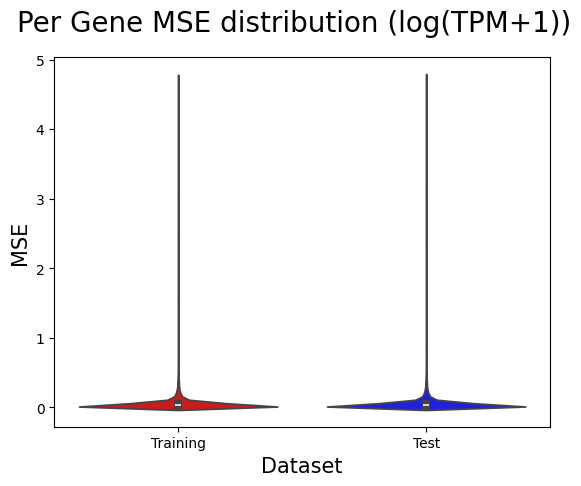

In [14]:
loss_violin_plot(log_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (log(TPM+1))')